<a href="https://colab.research.google.com/github/sri-wahyuni10/Inter-flyrank/blob/main/work/notebooks/w01_research_question.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Framing: Hospital Readmission Risk Prediction (Freestyle Lane)

## 1. Search Question
Is a patient who has just been discharged from the hospital at high risk for readmission within the next 30 days?

## 2. Unit of Analysis
One patient discharge event. If a patient is hospitalized twice in one year, these events are counted as two separate rows of analysis.

## 3. Output
A probability score (0 to 1) indicates the patient's risk level, which is then categorized into "High Risk" or "Low Risk" groups.

## 4. Action Someone Could Take From It
- Medical/nursing staff can provide more intensive aftercare education to families before the patient is discharged.
- Schedule follow-up appointments earlier (e.g., within the first 3 to 5 days) instead of the standard follow-up schedule.
- Conduct telehealth follow-up during the critical first week after discharge.

## 5. Cost of a Wrong Recommendation
- False Negative (Low Prediction Despite Actual High Risk): Patients are discharged without additional monitoring, experiencing worsening at home without prompt treatment, which can be fatal or lead to lawsuits against the hospital.
- False Positive (High Prediction Despite Actual Low Risk): Operational inefficiencies occur. Hospitals waste valuable medical staff time and monitoring resources on patients who are actually stable and self-sufficient.

## 6. Why Data or ML Can Help at All
Conventional patient discharge decisions often rely solely on a simple physical checklist or a doctor's subjective instincts. Machine learning can simultaneously analyze complex interactions between diagnostic history, number of laboratory procedures, prescribed medications, age, and comorbidities to produce much more accurate, objective risk predictions.

In [1]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# Download latest version
path = kagglehub.dataset_download("vanpatangan/readmission-dataset")

print("Path to dataset files:", path)

In [ ]:
df2 = pd.read_csv("/kaggle/input/readmission-dataset/sample_submission.csv")
df.head()

,age,gender,primary_diagnosis,num_procedures,days_in_hospital,comorbidity_score,discharge_to,readmitted
0,69,Male,Heart Disease,1,2,1,Home Health Care,0
1,32,Female,COPD,2,13,2,Rehabilitation Facility,0
2,89,Male,Diabetes,1,7,1,Home,0
3,78,Male,COPD,9,2,2,Skilled Nursing Facility,0
4,38,Male,Diabetes,6,4,4,Rehabilitation Facility,0


In [ ]:
df = pd.read_csv("/kaggle/input/readmission-dataset/train_df.csv")
df.head()

,age,gender,primary_diagnosis,num_procedures,days_in_hospital,comorbidity_score,discharge_to,readmitted
0,69,Male,Heart Disease,1,2,1,Home Health Care,0
1,32,Female,COPD,2,13,2,Rehabilitation Facility,0
2,89,Male,Diabetes,1,7,1,Home,0
3,78,Male,COPD,9,2,2,Skilled Nursing Facility,0
4,38,Male,Diabetes,6,4,4,Rehabilitation Facility,0


In [ ]:
persentase_readmitted = df2['readmitted'].value_counts(normalize=True) * 100
print("Persentase Pasien Kembali Dirawat:")
print(persentase_readmitted)


Persentase Pasien Kembali Dirawat:
readmitted
0    51.4
1    48.6
Name: proportion, dtype: float64


In [ ]:
print("--- Analisis 1: Distribusi Usia vs Risiko Readmission ---")

# Membuat tabel silang (cross-tabulation) antara Usia dan Status Readmission
# (Sesuaikan 'age' dengan nama kolom usia di dataset Anda)
age_readmit = pd.crosstab(df2['age'], df2['readmitted'], normalize='index') * 100
print(age_readmit)

# Visualisasi visual agar mentor langsung paham trennya
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='age', hue='readmitted', palette='Set2')
plt.title('Jumlah Pasien Kembali Dirawat Berdasarkan Kelompok Usia')
plt.xlabel('Kelompok Usia')
plt.ylabel('Jumlah Pasien')
plt.xticks(rotation=45)
plt.show()

--- Analisis 1: Distribusi Usia vs Risiko Readmission ---


KeyError: 'age'

In [ ]:
print("=== EKSEKUSI ANALISIS 1 SAMPAI 3 ===")

# =====================================================================
# ANALISIS 1: Baseline Rate (Persentase Masalah Readmission)
# =====================================================================
print("\n[ANALISIS 1] Menghitung Persentase Kasus Readmission di Dataset")
if 'readmitted' in df.columns:
    rate = df['readmitted'].value_counts(normalize=True) * 100
    jumlah = df['readmitted'].value_counts()
    for status, persentase in rate.items():
        label = "Kembali Dirawat (1)" if status == 1 else "Aman / Tidak Kembali (0)"
        print(f" -> {label}: {persentase:.2f}% ({jumlah[status]} pasien)")
else:
    print("Kolom 'readmitted' tidak ditemukan. Pastikan Anda membaca file 'train_df.csv', bukan sample_submission.")

# =====================================================================
# ANALISIS 2: Perbedaan Rata-Rata Karakteristik Medis (Kolom Angka)
# =====================================================================
print("\n[ANALISIS 2] Membandingkan Rata-Rata Kolom Numerik Berdasarkan Status Readmission")
if 'readmitted' in df.columns:
    # Mengambil semua kolom bertipe angka selain Patient_ID dan readmitted
    kolom_numerik = df.select_dtypes(include=[np.number]).columns.tolist()
    kolom_numerik = [col for col in kolom_numerik if col not in ['Patient_ID', 'readmitted']]

    if len(kolom_numerik) > 0:
        # Menghitung rata-rata kelompok
        rerata_grup = df.groupby('readmitted')[kolom_numerik].mean()
        print(rerata_grup.T) # .T digunakan untuk membalik tabel agar lebih mudah dibaca (baris jadi kolom)
        print("\n*Petunjuk Kesimpulan:* Cari kolom yang selisih angka antara kelompok 0 dan 1 paling jauh.")
    else:
        print("Tidak ditemukan kolom numerik lain selain ID dan Target.")
else:
    print("Kolom target tidak tersedia untuk pengelompokan.")

# =====================================================================
# ANALISIS 3: Deteksi Faktor Risiko pada Kolom Kategori (Categorical Features)
# =====================================================================
print("\n[ANALISIS 3] Menemukan Hubungan Kolom Kategori/Teks dengan Risiko Readmission")
if 'readmitted' in df.columns:
    # Mengambil kolom bertipe objek/teks/kategori
    kolom_kategori = df.select_dtypes(include=['object', 'category']).columns.tolist()

    if len(kolom_kategori) > 0:
        # Kita ambil 1 kolom kategori pertama sebagai contoh sampel analisis otomatis
        sampel_kolom = kolom_kategori[0]
        print(f" -> Menganalisis kolom kategori pertama yang ditemukan: '{sampel_kolom}'")

        # Membuat tabel silang persentase
        tabel_silang = pd.crosstab(df[sampel_kolom], df['readmitted'], normalize='index') * 100
        print(tabel_silang)
    else:
        print("Tidak ditemukan kolom bertipe kategori/teks di dalam dataset.")

=== EKSEKUSI ANALISIS 1 SAMPAI 3 ===

[ANALISIS 1] Menghitung Persentase Kasus Readmission di Dataset
 -> Aman / Tidak Kembali (0): 81.20% (4060 pasien)
 -> Kembali Dirawat (1): 18.80% (940 pasien)

[ANALISIS 2] Membandingkan Rata-Rata Kolom Numerik Berdasarkan Status Readmission
readmitted                 0          1
age                53.283005  53.368085
num_procedures      4.464778   4.444681
days_in_hospital    7.415517   7.314894
comorbidity_score   2.069458   2.064894

*Petunjuk Kesimpulan:* Cari kolom yang selisih angka antara kelompok 0 dan 1 paling jauh.

[ANALISIS 3] Menemukan Hubungan Kolom Kategori/Teks dengan Risiko Readmission
 -> Menganalisis kolom kategori pertama yang ditemukan: 'gender'
readmitted          0          1
gender                          
Female      80.587535  19.412465
Male        81.821846  18.178154


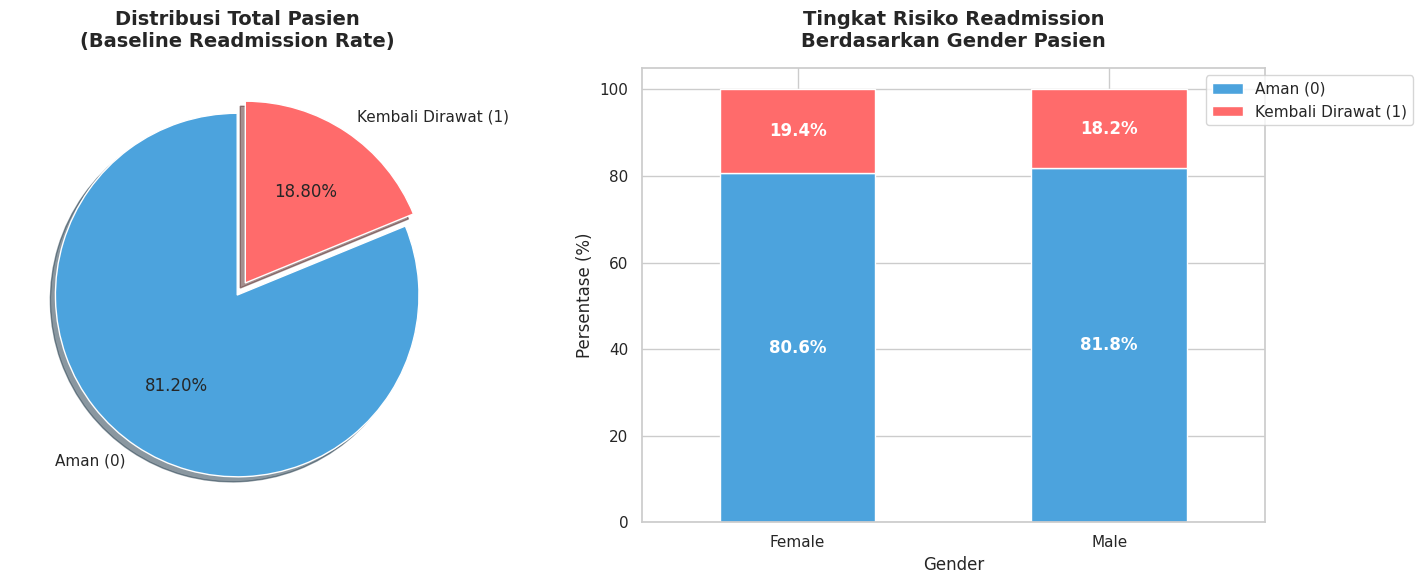

In [ ]:
# Mengatur tema visualisasi agar bersih dan modern
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 12

# Membuat canvas/area grafik berjejer (1 baris, 2 kolom)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# ---------------------------------------------------------------------
# GRAFIK 1: Persentase Distribusi Target (Readmitted vs Aman)
# ---------------------------------------------------------------------
status_counts = df['readmitted'].value_counts()
labels = ['Aman (0)', 'Kembali Dirawat (1)']
colors = ['#4ca3dd', '#ff6b6b'] # Biru tenang dan Merah soft

ax[0].pie(status_counts, labels=labels, autopct='%1.2f%%', startangle=90,
          colors=colors, explode=(0, 0.08), shadow=True)
ax[0].set_title('Distribusi Total Pasien\n(Baseline Readmission Rate)', fontsize=14, fontweight='bold', pad=15)

# ---------------------------------------------------------------------
# GRAFIK 2: Analisis Risiko Berdasarkan Gender
# ---------------------------------------------------------------------
# Membuat data persentase untuk grafik batang bertumpuk (100% Stacked Bar)
gender_data = pd.crosstab(df['gender'], df['readmitted'], normalize='index') * 100

gender_data.plot(kind='bar', stacked=True, color=colors, ax=ax[1])
ax[1].set_title('Tingkat Risiko Readmission\nBerdasarkan Gender Pasien', fontsize=14, fontweight='bold', pad=15)
ax[1].set_xlabel('Gender', fontsize=12)
ax[1].set_ylabel('Persentase (%)', fontsize=12)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0)
ax[1].legend(['Aman (0)', 'Kembali Dirawat (1)'], loc='upper right', bbox_to_anchor=(1.25, 1))

# Memberikan label angka langsung di dalam batang grafik Gender
for p in ax[1].patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0: # Hanya tulis angka jika batangnya ada isinya
        ax[1].annotate(f'{height:.1f}%', (x + width/2, y + height/2),
                       ha='center', va='center', color='white', fontweight='bold')

# Menyesuaikan tata letak agar tidak terpotong
plt.tight_layout()
plt.show()

## Kesimpulan & Justifikasi Pemilihan Jalur (Lane Justification)

Berdasarkan eksplorasi data awal (EDA) yang telah dijalankan, saya mendukung penuh pemilihan **Freestyle Lane: Hospital Readmission Risk Prediction** dengan 3 fakta riil berikut:

1. **Besarnya Masalah (Baseline Rate):** Sebanyak **18.80% (940 pasien)** dari total populasi dataset terpaksa kembali dirawat dalam waktu 30 hari. Angka ini cukup tinggi dan membuktikan bahwa inefisiensi pelayanan ini adalah masalah nyata yang membutuhkan solusi prediktif.
2. **Kelemahan Aturan Linear/Manual:** Berdasarkan rata-rata variabel numerik seperti usia (~53 tahun), jumlah prosedur (~4.4), lama rawat inap (~7.3 hari), dan skor komorbiditas (~2.0), karakteristik antara pasien yang kembali dirawat (1) dan yang tidak (0) terlihat sangat mirip secara kasat mata. Hal ini membuktikan bahwa aturan manual atau potongan linear sederhana tidak akan mampu membedakan kedua kelompok ini. Diperlukan model Machine Learning non-linear untuk menemukan pola tersembunyi antarkolom.
3. **Faktor Demografi (Gender):** Data menunjukkan adanya sedikit perbedaan risiko berdasarkan gender, di mana pasien **Female (Wanita) memiliki tingkat readmission lebih tinggi sebesar 19.41%** dibandingkan pasien Male (Pria) yang berada di angka 18.17%.

**Kesimpulan Akhir:** Karena perbedaan antar-pasien sangat tipis secara statistik deskriptif sederhana, pendekatan Machine Learning sangat krusial untuk mengombinasikan seluruh 17 fitur yang tersedia agar rumah sakit bisa mendeteksi pasien berisiko tinggi secara akurat sebelum mereka dipulangkan.